In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%pip install pandas numpy matplotlib

     ---------------------------------------- 11.3/11.3 MB 5.1 MB/s eta 0:00:00
     ---------------------------------------- 12.9/12.9 MB 5.5 MB/s eta 0:00:00
     ---------------------------------------- 8.2/8.2 MB 6.1 MB/s eta 0:00:00
     -------------------------------------- 508.3/508.3 kB 6.4 MB/s eta 0:00:00
     ------------------------------------- 348.2/348.2 kB 10.9 MB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 7.1 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     -------------------------------------- 221.2/221.2 kB 4.5 MB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 6.2 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
     ---------------------------------------- 73.4/73.4 kB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
df=pd.read_csv('../Dataset/Sample - Superstore.csv',encoding="latin1")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.shape

(9994, 21)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

# Step 1 — Check data types and non-null values

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Step 2 — Check missing values

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Step 3 — Check duplicate rows

In [12]:
df.duplicated().sum()

np.int64(0)

# Next: Convert the dates

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [14]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

# Overall Business KPIs

In [15]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793
Profit Margin: 12.47 %


# Descriptive Statistics

In [16]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


# Category Analysis

In [17]:
category_summary = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).round(2)

category_summary

,Total_Sales,Total_Profit
Category,,
Furniture,741999.80,18451.27
Office Supplies,719047.03,122490.80
Technology,836154.03,145454.95


# First Visualization

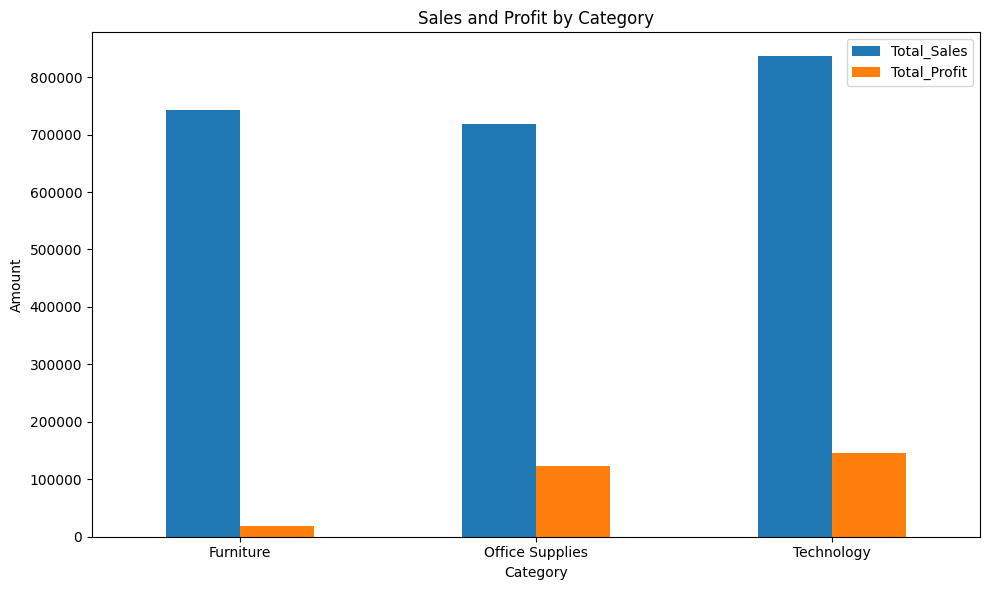

In [18]:
category_summary.plot(
    kind="bar",
    y=["Total_Sales", "Total_Profit"],
    figsize=(10, 6)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Sub-Category Profitability

In [19]:
subcategory_summary = df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).round(2)

subcategory_summary.sort_values(
    "Total_Profit",
    ascending=True
)

,Total_Sales,Total_Profit
Sub-Category,,
Tables,206965.53,-17725.48
Bookcases,114880.00,-3472.56
Supplies,46673.54,-1189.10
Fasteners,3024.28,949.52
Machines,189238.63,3384.76
Labels,12486.31,5546.25
Art,27118.79,6527.79
Envelopes,16476.40,6964.18
Furnishings,91705.16,13059.14


# Task 8 — Visualize Sub-Category Profitability

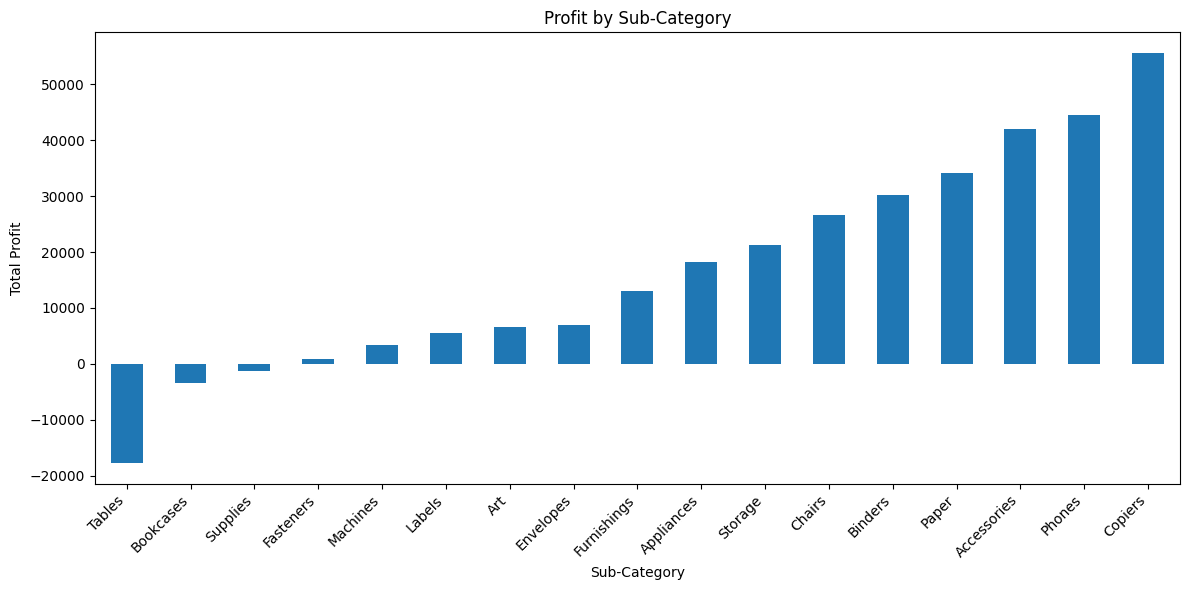

In [20]:
subcategory_profit = subcategory_summary.sort_values(
    "Total_Profit",
    ascending=True
)

subcategory_profit["Total_Profit"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Task 9 — Regional Performance

In [21]:
region_summary = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).round(2)

region_summary

,Total_Sales,Total_Profit
Region,,
Central,501239.89,39706.36
East,678781.24,91522.78
South,391721.90,46749.43
West,725457.82,108418.45


# Task 10 — Regional Sales & Profit Visualization

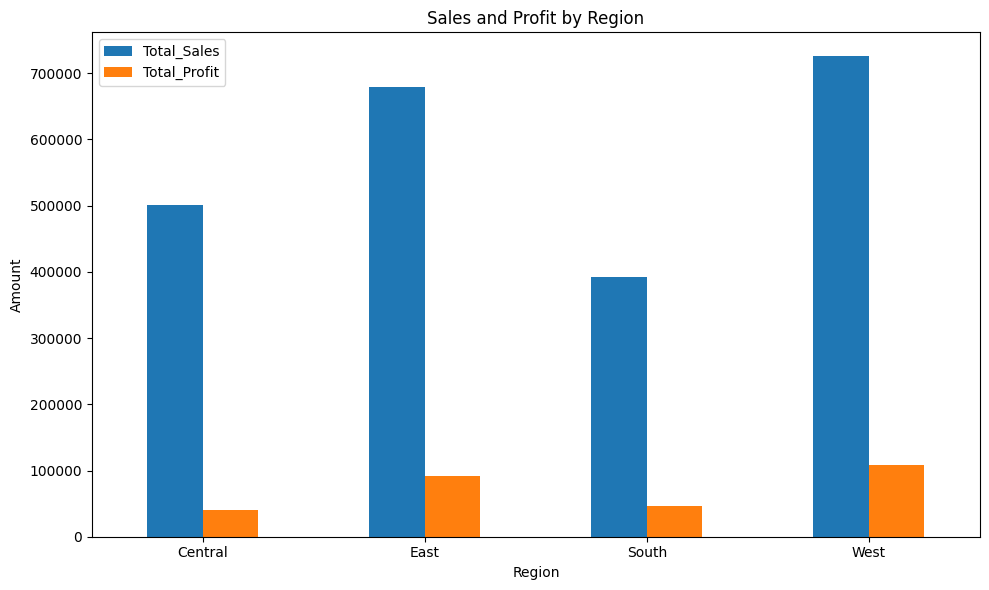

In [22]:
region_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Task 11 — Customer Segment Analysis

In [23]:
segment_summary = df.groupby("Segment").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Customers=("Customer ID", "nunique")
).round(2)

segment_summary

,Total_Sales,Total_Profit,Total_Customers
Segment,,,
Consumer,1161401.34,134119.21,409
Corporate,706146.37,91979.13,236
Home Office,429653.15,60298.68,148


# Task 12 — Segment Visualization

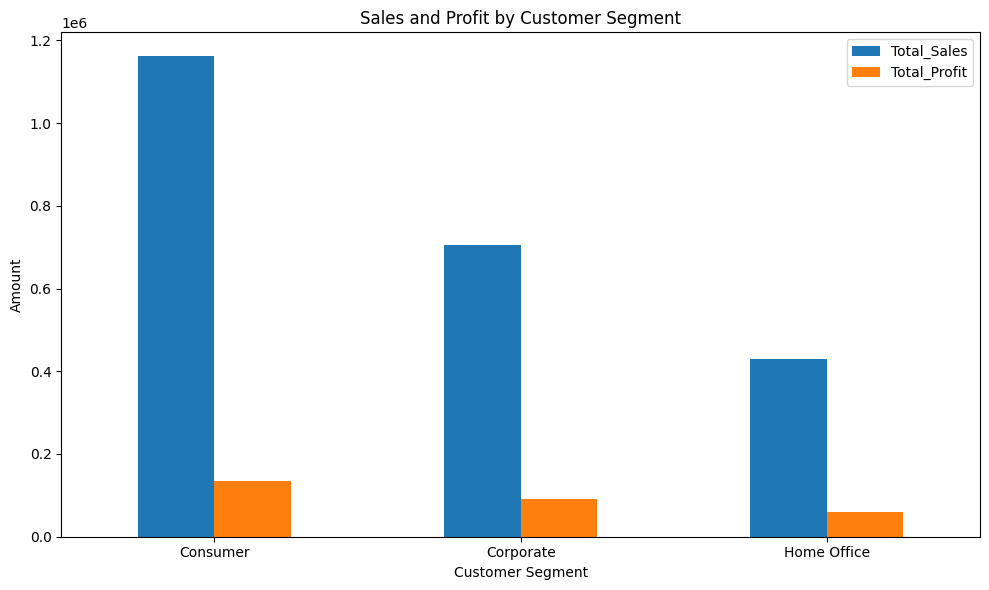

In [24]:
segment_summary[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Task 13 — Top 10 Customers by Sales

In [25]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

top_customers

Customer Name
Sean Miller           25043.05
Tamara Chand          19052.22
Raymond Buch          15117.34
Tom Ashbrook          14595.62
Adrian Barton         14473.57
Ken Lonsdale          14175.23
Sanjit Chand          14142.33
Hunter Lopez          12873.30
Sanjit Engle          12209.44
Christopher Conant    12129.07
Name: Sales, dtype: float64

# Task 14 — Visualize Top 10 Customers

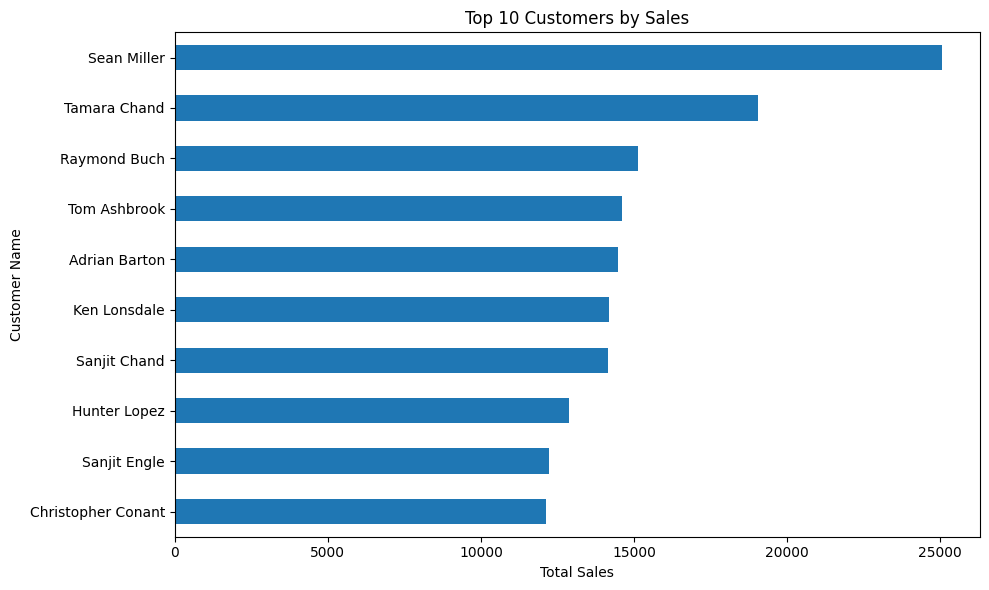

In [26]:
top_customers.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()

# Task 15 — Top 10 Customers by Profit

In [27]:
top_profit_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

top_profit_customers

Customer Name
Tamara Chand            8981.32
Raymond Buch            6976.10
Sanjit Chand            5757.41
Hunter Lopez            5622.43
Adrian Barton           5444.81
Tom Ashbrook            4703.79
Christopher Martinez    3899.89
Keith Dawkins           3038.63
Andy Reiter             2884.62
Daniel Raglin           2869.08
Name: Profit, dtype: float64

# Task 16 — Visualize Top 10 Customers by Profit

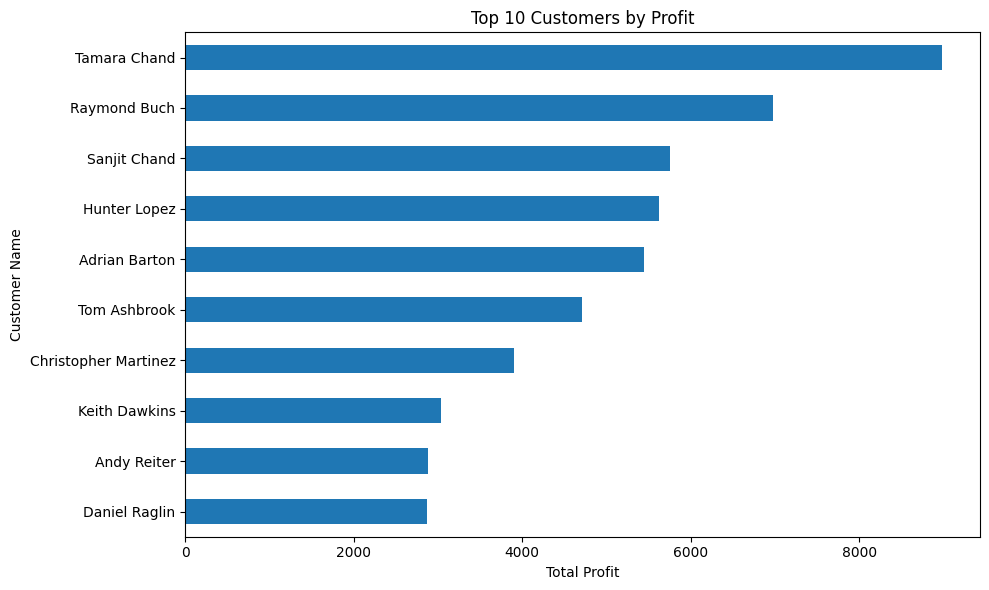

In [28]:
top_profit_customers.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()

# Task 17 — Discount & Profitability Analysis

In [29]:
discount_summary = df.groupby("Discount").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).round(2)

discount_summary

,Total_Sales,Total_Profit
Discount,,
0.00,1087908.47,320987.60
0.10,54369.35,9029.18
0.15,27558.52,1418.99
0.20,764594.37,90337.31
0.30,103226.66,-10369.28
0.32,14493.46,-2391.14
0.40,116417.78,-23057.05
0.45,5484.97,-2493.11
0.50,58918.54,-20506.43


# Discount vs Profit Visualization

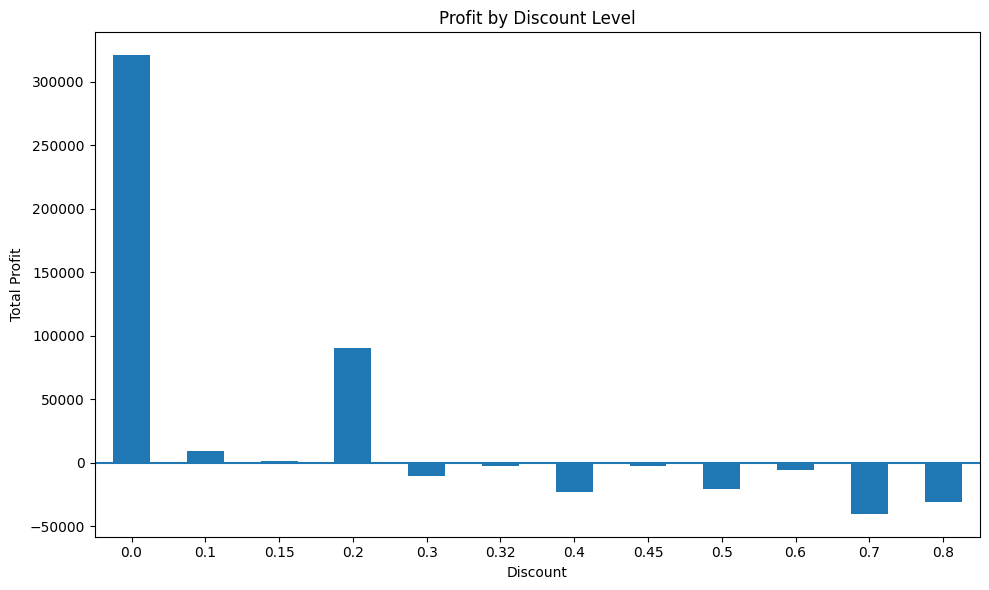

In [30]:
discount_summary["Total_Profit"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.axhline(0)
plt.tight_layout()
plt.show()

# Task 19 — Ship Mode Analysis

In [31]:
ship_mode_summary = df.groupby("Ship Mode").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).round(2)

ship_mode_summary

,Total_Sales,Total_Profit
Ship Mode,,
First Class,351428.42,48969.84
Same Day,128363.12,15891.76
Second Class,459193.57,57446.64
Standard Class,1358215.74,164088.79


# Task 20 — Ship Mode Visualization

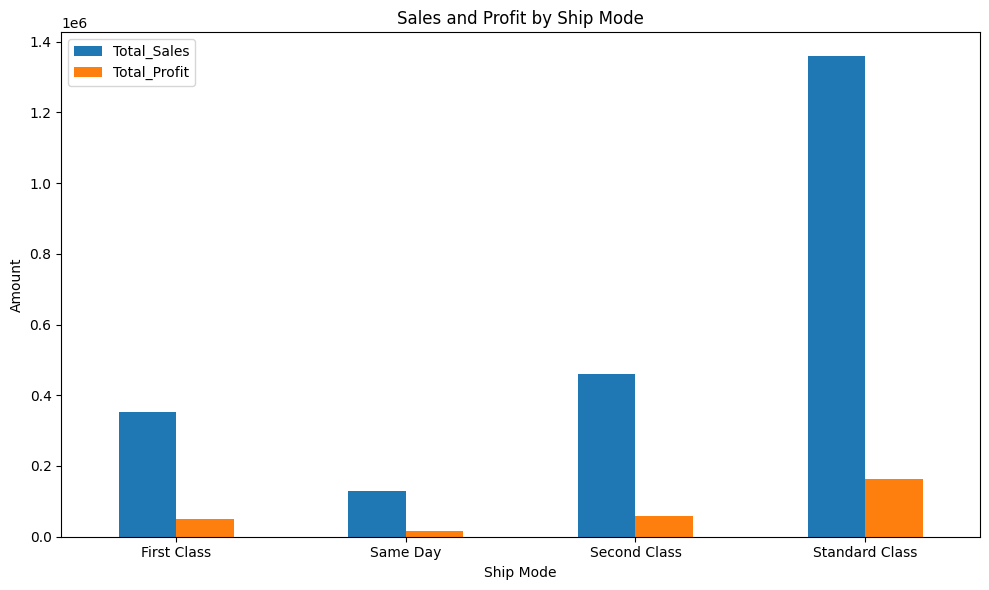

In [32]:
ship_mode_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Task 21 — Monthly Sales Trend

In [33]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales

Order Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


# Monthly Sales Trend Visualization

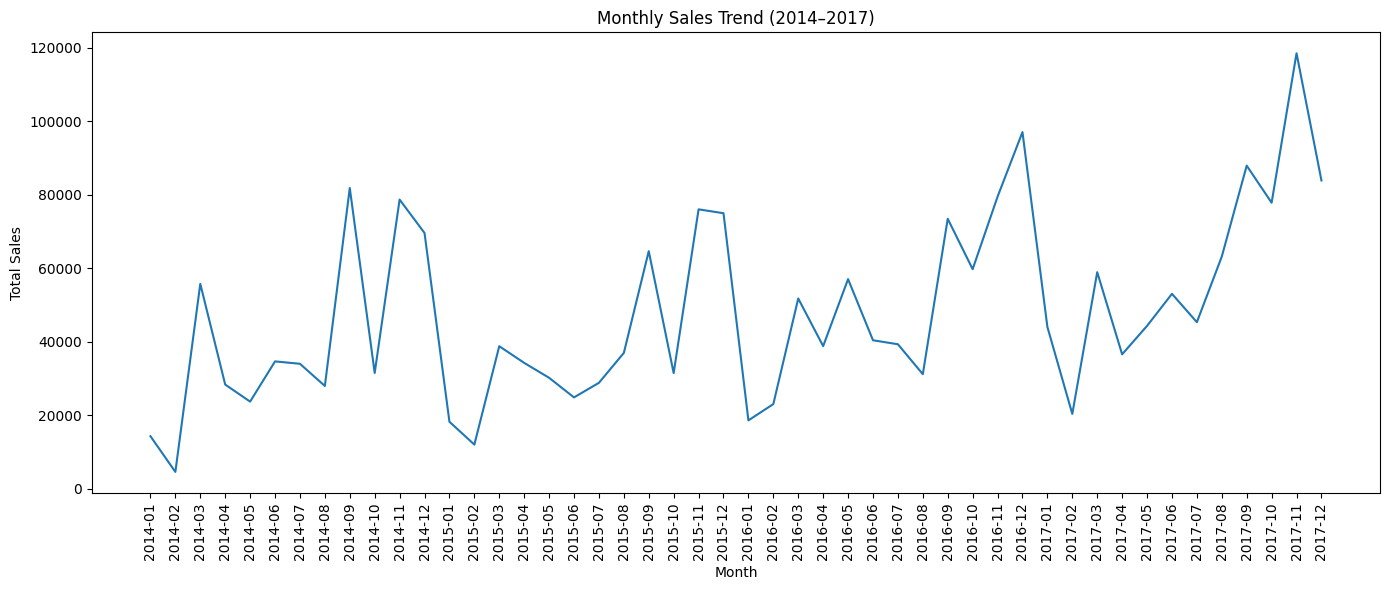

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Sales Trend (2014–2017)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Task 23 — Yearly Sales & Year-over-Year Growth

In [35]:
yearly_sales = (
    df.groupby(df["Order Date"].dt.year)["Sales"]
    .sum()
    .round(2)
)

yearly_growth = yearly_sales.pct_change().mul(100).round(2)

yearly_summary = pd.DataFrame({
    "Total_Sales": yearly_sales,
    "YoY_Growth": yearly_growth
})

yearly_summary

,Total_Sales,YoY_Growth
Order Date,,
2014,484247.50,NaN
2015,470532.51,-2.83
2016,609205.60,29.47
2017,733215.26,20.36


# Yearly Sales Growth Visualization

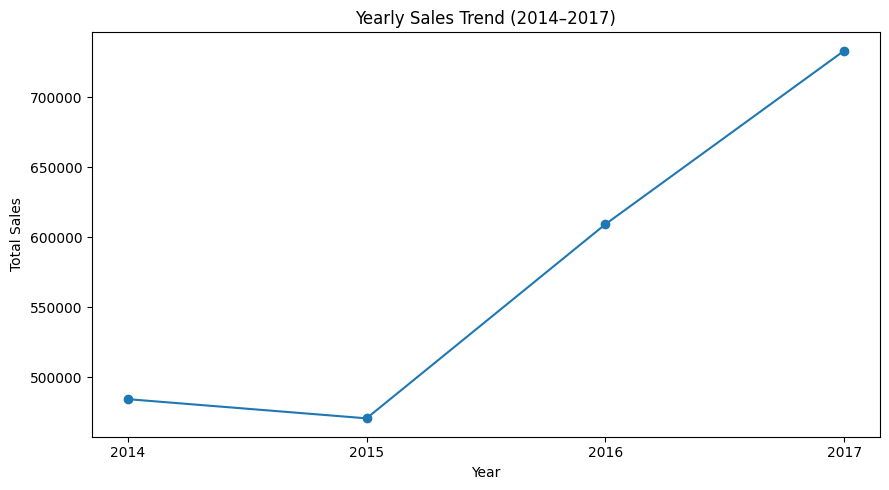

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    yearly_summary.index,
    yearly_summary["Total_Sales"],
    marker="o"
)

plt.title("Yearly Sales Trend (2014–2017)")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(yearly_summary.index)
plt.tight_layout()
plt.show()

# Task 25 — Customer Sales & Profit Analysis

In [37]:
customer_summary = (
    df.groupby("Customer Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
    .round(2)
)

customer_summary.head(10)

,Total_Sales,Total_Profit,Total_Orders
Customer Name,,,
Sean Miller,25043.05,-1980.74,5
Tamara Chand,19052.22,8981.32,5
Raymond Buch,15117.34,6976.10,6
Tom Ashbrook,14595.62,4703.79,4
Adrian Barton,14473.57,5444.81,10
Ken Lonsdale,14175.23,806.86,12
Sanjit Chand,14142.33,5757.41,9
Hunter Lopez,12873.30,5622.43,6
Sanjit Engle,12209.44,2650.68,11


# Task 26 — Identify Loss-Making Customers

In [38]:
loss_making_customers = customer_summary[
    customer_summary["Total_Profit"] < 0
]

loss_making_customers.shape

(155, 3)

In [39]:
loss_making_customers.head(10)

,Total_Sales,Total_Profit,Total_Orders
Customer Name,,,
Sean Miller,25043.05,-1980.74,5
Becky Martin,11789.63,-1659.96,4
Grant Thornton,9351.21,-4108.66,3
Peter Fuller,9062.86,-614.29,4
Natalie Fritzler,8322.83,-1695.97,7
Sean Braxton,8057.89,-2082.75,7
Zuschuss Carroll,8025.71,-1032.15,13
Joseph Holt,7955.00,-644.70,6
Joseph Airdo,6491.03,-819.42,8


# Task 27 — Visualize Top Loss-Making Customers

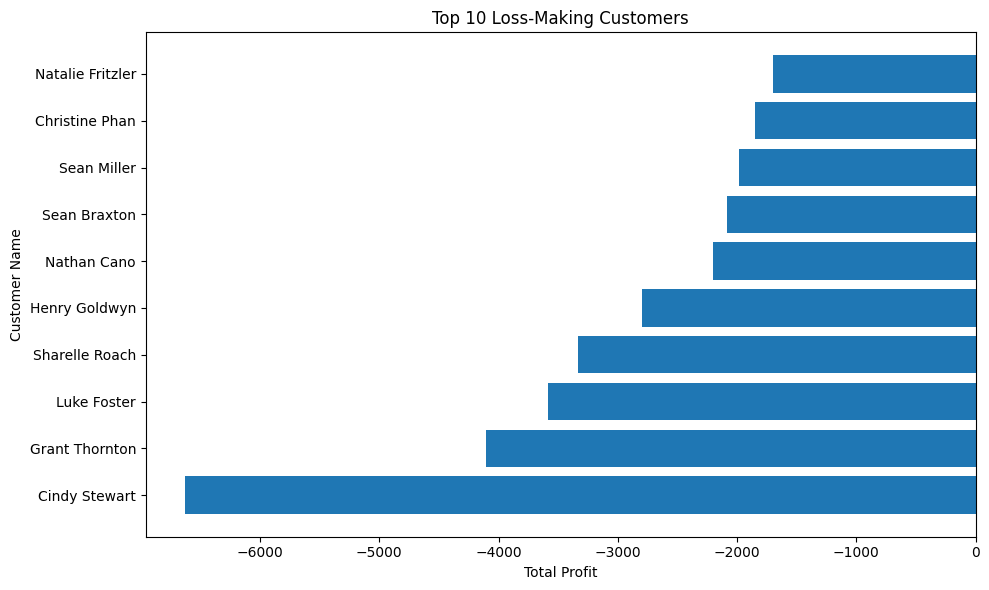

In [40]:
top_loss_customers = (
    loss_making_customers
    .sort_values("Total_Profit")
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_loss_customers.index,
    top_loss_customers["Total_Profit"]
)

plt.title("Top 10 Loss-Making Customers")
plt.xlabel("Total Profit")
plt.ylabel("Customer Name")

plt.tight_layout()
plt.show()

# Task 28 — Product Performance Analysis

In [41]:
product_summary = (
    df.groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
    .round(2)
)

product_summary.head(10)

,Total_Sales,Total_Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08
HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00
GBC DocuBind TL300 Electric Binding System,19823.48,2233.51
GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17


# Task 29 — Top 10 Products by Sales Visualization

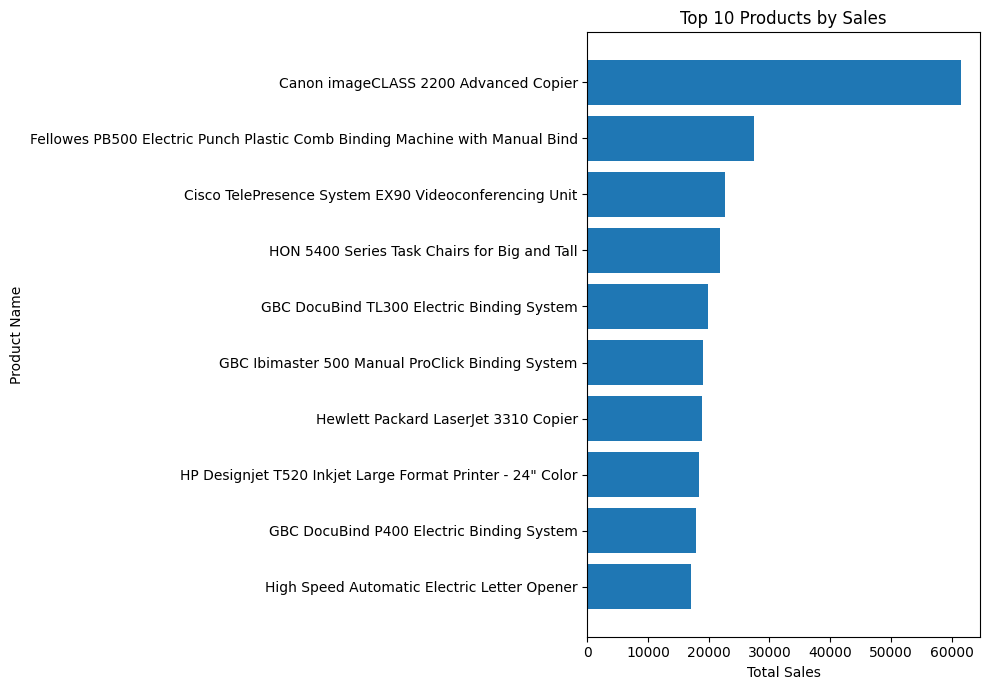

In [42]:
top_products = product_summary.head(10).sort_values("Total_Sales")

plt.figure(figsize=(10, 7))

plt.barh(
    top_products.index,
    top_products["Total_Sales"]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

# Task 30 — Top 10 Products by Profit

In [43]:
top_profit_products = (
    product_summary
    .sort_values("Total_Profit", ascending=False)
    .head(10)
    .sort_values("Total_Profit")
)

top_profit_products

,Total_Sales,Total_Profit
Product Name,,
Zebra ZM400 Thermal Label Printer,6965.70,3343.54
Ibico EPK-21 Electric Binding System,15875.92,3345.28
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.29,3696.28
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97
Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98
Canon PC1060 Personal Laser Copier,11619.83,4570.93
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04


# Task 31 — Top 10 Products by Profit Visualization

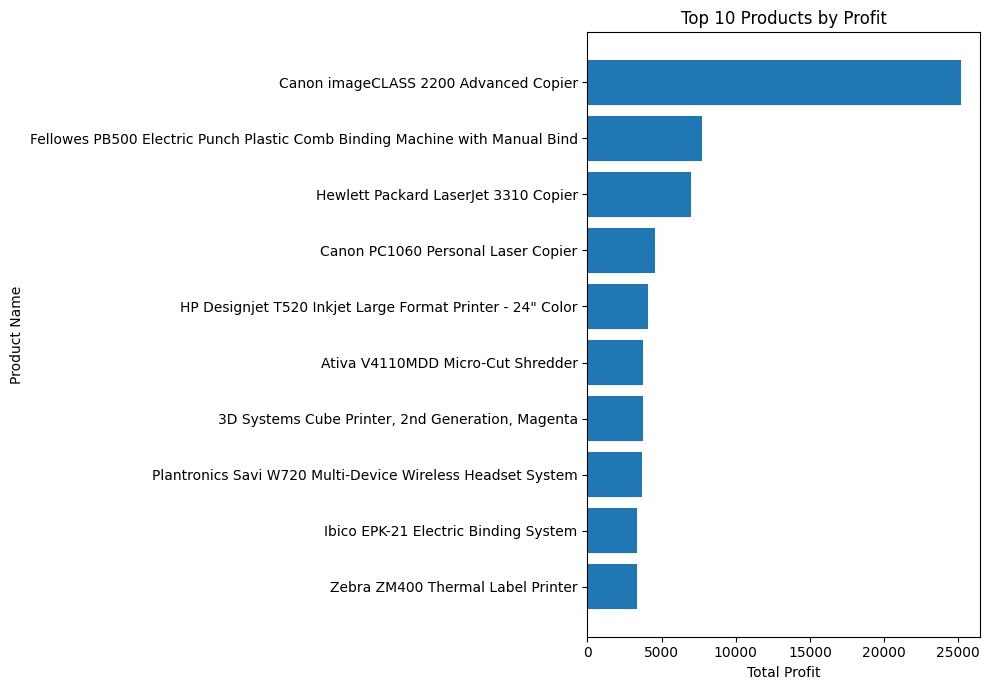

In [44]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_profit_products.index,
    top_profit_products["Total_Profit"]
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

# Task 32 — Regional Customer Analysis

In [45]:
region_customer = (
    df.groupby(["Region", "Customer Name"])["Sales"]
    .sum()
    .reset_index(name="Total_Sales")
)

region_customer["Sales_Rank"] = (
    region_customer.groupby("Region")["Total_Sales"]
    .rank(method="min", ascending=False)
)

top_region_customers = (
    region_customer[region_customer["Sales_Rank"] <= 3]
    .sort_values(["Region", "Sales_Rank"])
)

top_region_customers

,Region,Customer Name,Total_Sales,Sales_Rank
579,Central,Tamara Chand,18437.138,1.0
5,Central,Adrian Barton,12181.594,2.0
57,Central,Becky Martin,10539.896,3.0
1276,East,Tom Ashbrook,13723.498,1.0
916,East,Hunter Lopez,10522.550,2.0
705,East,Bill Shonely,10022.293,3.0
1745,South,Sean Miller,23669.196,1.0
1736,South,Sanjit Engle,8805.040,2.0
1499,South,Grant Thornton,8167.420,3.0
2354,West,Raymond Buch,14345.276,1.0


# Task 33 — Regional Customer Visualization

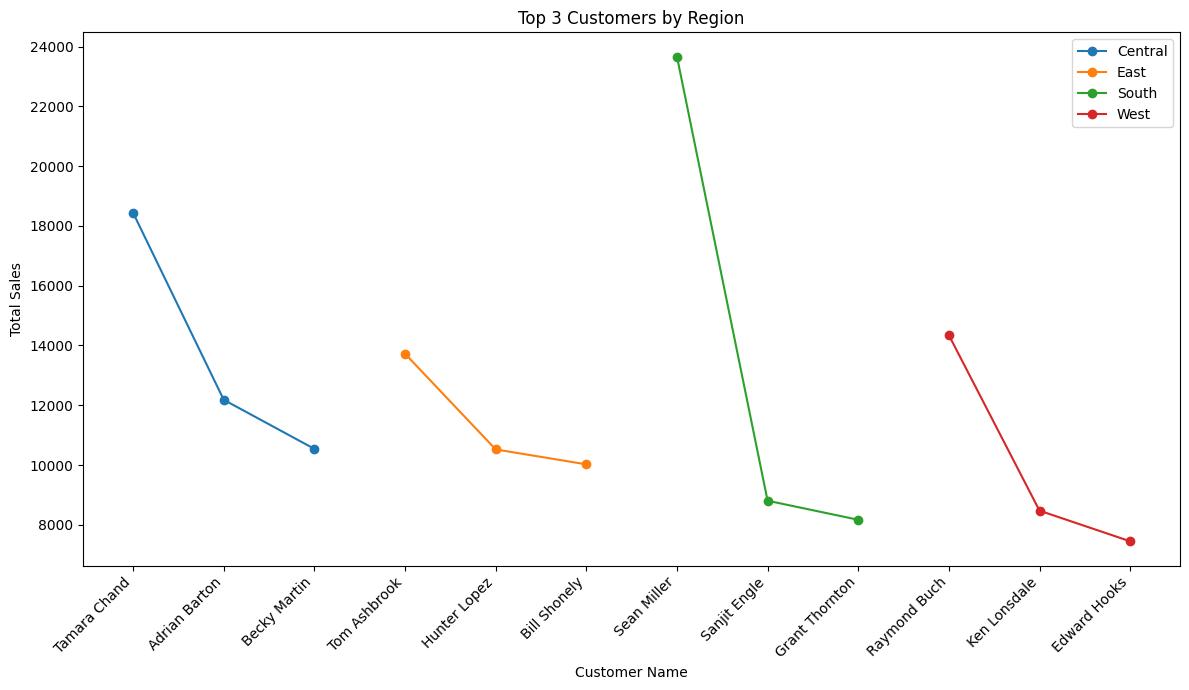

In [46]:
plt.figure(figsize=(12, 7))

for region in top_region_customers["Region"].unique():
    data = top_region_customers[
        top_region_customers["Region"] == region
    ]
    
    plt.plot(
        data["Customer Name"],
        data["Total_Sales"],
        marker="o",
        label=region
    )

plt.title("Top 3 Customers by Region")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# Task 34 — Profit Margin by Region

In [47]:
region_profit = (
    df.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

region_profit["Profit_Margin"] = (
    region_profit["Total_Profit"]
    / region_profit["Total_Sales"]
    * 100
).round(2)

region_profit.round(2)

,Total_Sales,Total_Profit,Profit_Margin
Region,,,
Central,501239.89,39706.36,7.92
East,678781.24,91522.78,13.48
South,391721.90,46749.43,11.93
West,725457.82,108418.45,14.94


# Task 35 — Profit Margin Visualization

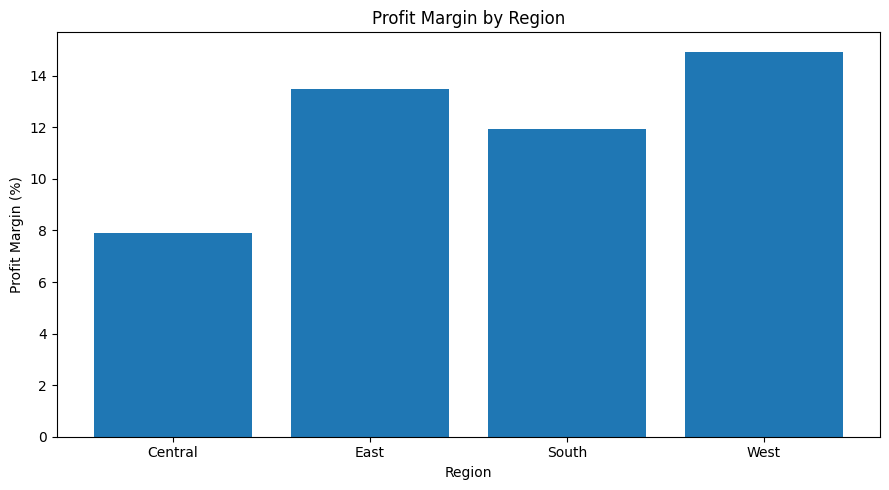

In [48]:
plt.figure(figsize=(9, 5))

plt.bar(
    region_profit.index,
    region_profit["Profit_Margin"]
)

plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

# Task 36 — Category Profitability Analysis

In [49]:
category_profit = (
    df.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

category_profit["Profit_Margin"] = (
    category_profit["Total_Profit"]
    / category_profit["Total_Sales"]
    * 100
).round(2)

category_profit.round(2)

,Total_Sales,Total_Profit,Profit_Margin
Category,,,
Furniture,741999.80,18451.27,2.49
Office Supplies,719047.03,122490.80,17.04
Technology,836154.03,145454.95,17.40


# Task 37 — Category Profit Margin Visualization

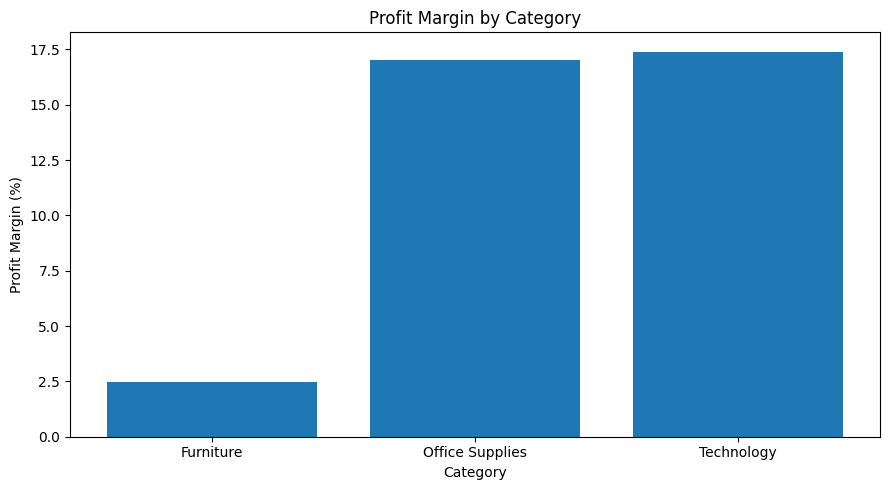

In [50]:
plt.figure(figsize=(9, 5))

plt.bar(
    category_profit.index,
    category_profit["Profit_Margin"]
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

# Task 38 — Sub-Category Profitability Analysis

In [51]:
subcategory_profit = (
    df.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

subcategory_profit["Profit_Margin"] = (
    subcategory_profit["Total_Profit"]
    / subcategory_profit["Total_Sales"]
    * 100
).round(2)

subcategory_profit = (
    subcategory_profit
    .sort_values("Total_Profit")
)

subcategory_profit.round(2)

,Total_Sales,Total_Profit,Profit_Margin
Sub-Category,,,
Tables,206965.53,-17725.48,-8.56
Bookcases,114880.00,-3472.56,-3.02
Supplies,46673.54,-1189.10,-2.55
Fasteners,3024.28,949.52,31.40
Machines,189238.63,3384.76,1.79
Labels,12486.31,5546.25,44.42
Art,27118.79,6527.79,24.07
Envelopes,16476.40,6964.18,42.27
Furnishings,91705.16,13059.14,14.24


# Task 39 — Sub-Category Profitability Visualization

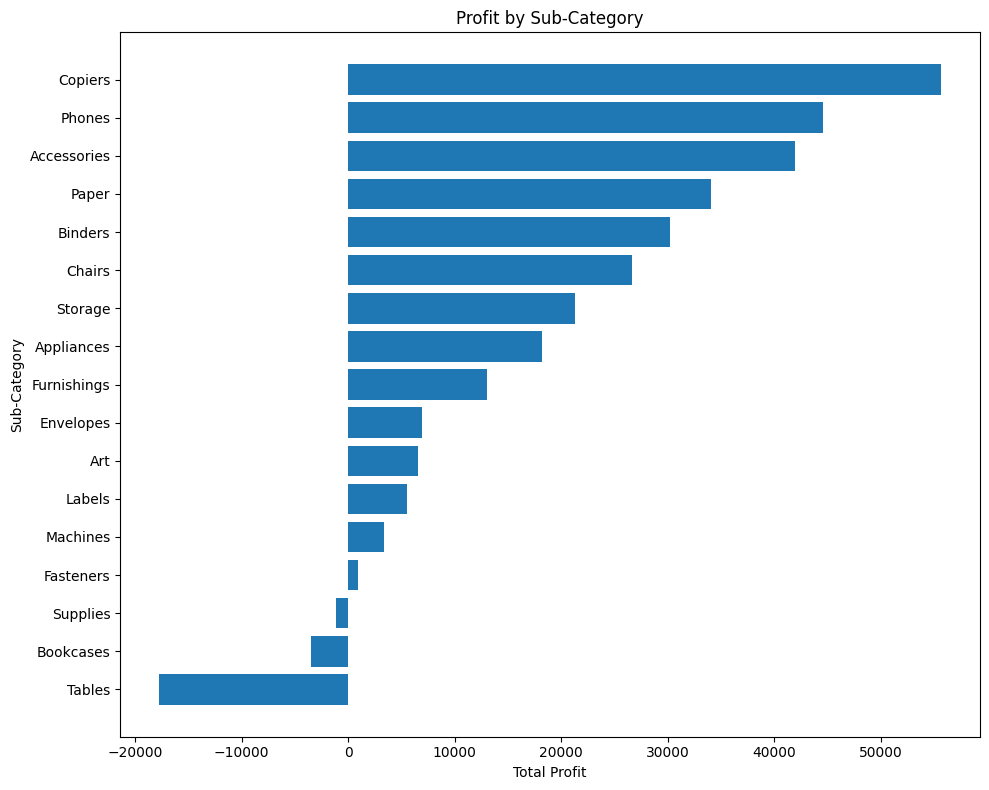

In [52]:
plt.figure(figsize=(10, 8))

plt.barh(
    subcategory_profit.index,
    subcategory_profit["Total_Profit"]
)

plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

# Python — Final Analysis 1: Correlation Analysis

Step 1 — Calculate correlations

In [53]:
correlation = df[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr().round(2)

correlation

,Sales,Quantity,Discount,Profit
Sales,1.00,0.20,-0.03,0.48
Quantity,0.20,1.00,0.01,0.07
Discount,-0.03,0.01,1.00,-0.22
Profit,0.48,0.07,-0.22,1.00


Step 2 — Visualize it

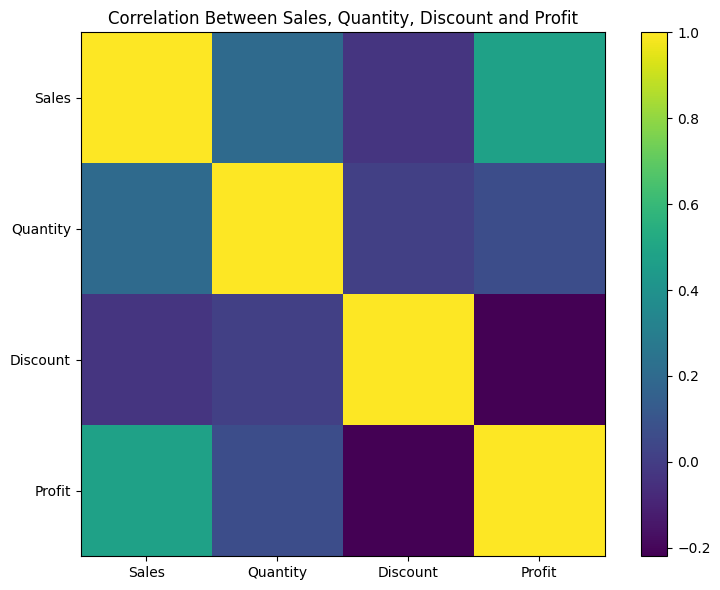

In [54]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Between Sales, Quantity, Discount and Profit")

plt.tight_layout()
plt.show()

# Final Python analysis: loss-making customers

In [55]:
customer_profit = (
    df.groupby("Customer Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order ID", "nunique")
    )
)

loss_making_customers = customer_profit[
    customer_profit["Total_Profit"] < 0
].sort_values("Total_Profit")

loss_making_customers.round(2)

,Total_Sales,Total_Profit,Total_Orders
Customer Name,,,
Cindy Stewart,5690.05,-6626.39,6
Grant Thornton,9351.21,-4108.66,3
Luke Foster,3930.51,-3583.98,7
Sharelle Roach,3233.48,-3333.91,5
Henry Goldwyn,3247.64,-2797.96,12
...,...,...,...
Thais Sissman,4.83,-3.32,2
Adrian Hane,1735.51,-2.31,7
Mitch Gastineau,16.74,-1.25,1


In [56]:
len(loss_making_customers)

155

# customer-level analysis with unique orders:

In [61]:
customer_analysis = df.groupby('Customer ID').agg(
    Customer_Name=('Customer Name', 'first'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

In [62]:
customer_analysis['Profit_Margin'] = (
    customer_analysis['Total_Profit'] /
    customer_analysis['Total_Sales']
)

In [63]:
customer_analysis.head(10)

,Customer ID,Customer_Name,Total_Sales,Total_Profit,Total_Orders,Profit_Margin
0,AA-10315,Alex Avila,5563.560,-362.8825,5,-0.065225
1,AA-10375,Allen Armold,1056.390,277.3824,9,0.262576
2,AA-10480,Andrew Allen,1790.512,435.8274,4,0.243409
3,AA-10645,Anna Andreadi,5086.935,857.8033,6,0.168629
4,AB-10015,Aaron Bergman,886.156,129.3465,3,0.145964
5,AB-10060,Adam Bellavance,7755.620,2054.5885,8,0.264916
6,AB-10105,Adrian Barton,14473.571,5444.8055,10,0.376190
7,AB-10150,Aimee Bixby,966.710,313.6597,5,0.324461
8,AB-10165,Alan Barnes,1113.838,220.8130,8,0.198245
9,AB-10255,Alejandro Ballentine,914.532,264.5675,9,0.289293


# Step 4 — Identify high-value but loss-making customers

In [64]:
high_value_loss = customer_analysis[
    (customer_analysis['Total_Profit'] < 0) &
    (customer_analysis['Total_Sales'] >= customer_analysis['Total_Sales'].quantile(0.75))
].sort_values('Total_Profit')

In [65]:
high_value_loss.head(10)

,Customer ID,Customer_Name,Total_Sales,Total_Profit,Total_Orders,Profit_Margin
180,CS-12505,Cindy Stewart,5690.055,-6626.3895,6,-1.164556
310,GT-14635,Grant Thornton,9351.212,-4108.6589,3,-0.439372
459,LF-17185,Luke Foster,3930.509,-3583.9770,7,-0.911835
666,SB-20290,Sean Braxton,8057.891,-2082.7451,7,-0.258473
700,SM-20320,Sean Miller,25043.050,-1980.7393,5,-0.079093
165,CP-12340,Christine Phan,5888.275,-1850.3029,8,-0.314235
560,NF-18385,Natalie Fritzler,8322.826,-1695.9714,7,-0.203774
90,BM-11140,Becky Martin,11789.630,-1659.9581,4,-0.140798
738,TB-21520,Tracy Blumstein,4737.486,-1603.0451,9,-0.338375
651,RO-19780,Rose O'Brian,3815.478,-1262.5716,7,-0.330908


In [66]:
high_value_loss[
    ['Customer ID', 'Customer_Name', 'Total_Sales',
     'Total_Profit', 'Total_Orders', 'Profit_Margin']
].head(10)

,Customer ID,Customer_Name,Total_Sales,Total_Profit,Total_Orders,Profit_Margin
180,CS-12505,Cindy Stewart,5690.055,-6626.3895,6,-1.164556
310,GT-14635,Grant Thornton,9351.212,-4108.6589,3,-0.439372
459,LF-17185,Luke Foster,3930.509,-3583.9770,7,-0.911835
666,SB-20290,Sean Braxton,8057.891,-2082.7451,7,-0.258473
700,SM-20320,Sean Miller,25043.050,-1980.7393,5,-0.079093
165,CP-12340,Christine Phan,5888.275,-1850.3029,8,-0.314235
560,NF-18385,Natalie Fritzler,8322.826,-1695.9714,7,-0.203774
90,BM-11140,Becky Martin,11789.630,-1659.9581,4,-0.140798
738,TB-21520,Tracy Blumstein,4737.486,-1603.0451,9,-0.338375
651,RO-19780,Rose O'Brian,3815.478,-1262.5716,7,-0.330908


# Customer Segmentation

In [67]:
customer_analysis['Customer_Segment'] = 'Low Value'

customer_analysis.loc[
    (customer_analysis['Total_Sales'] >= customer_analysis['Total_Sales'].median()) &
    (customer_analysis['Total_Profit'] >= 0),
    'Customer_Segment'
] = 'Profitable High Value'

customer_analysis.loc[
    (customer_analysis['Total_Sales'] >= customer_analysis['Total_Sales'].median()) &
    (customer_analysis['Total_Profit'] < 0),
    'Customer_Segment'
] = 'High Value Loss-Making'

customer_analysis.loc[
    (customer_analysis['Total_Sales'] < customer_analysis['Total_Sales'].median()) &
    (customer_analysis['Total_Profit'] >= 0),
    'Customer_Segment'
] = 'Low Value Profitable'

customer_analysis.loc[
    (customer_analysis['Total_Sales'] < customer_analysis['Total_Sales'].median()) &
    (customer_analysis['Total_Profit'] < 0),
    'Customer_Segment'
] = 'Low Value Loss-Making'

In [68]:
customer_analysis['Customer_Segment'].value_counts()

Customer_Segment
Profitable High Value     329
Low Value Profitable      309
Low Value Loss-Making      87
High Value Loss-Making     68
Name: count, dtype: int64

# investigate why they're loss-making

In [69]:
loss_customers = customer_analysis[
    customer_analysis['Customer_Segment'] == 'High Value Loss-Making'
]

loss_customer_ids = loss_customers['Customer ID'].tolist()

loss_customer_details = df[
    df['Customer ID'].isin(loss_customer_ids)
]

In [70]:
loss_customer_details.groupby('Customer ID').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Average_Discount=('Discount', 'mean'),
    Total_Quantity=('Quantity', 'sum')
).sort_values('Total_Profit').head(10)

,Total_Sales,Total_Profit,Average_Discount,Total_Quantity
Customer ID,,,,
CS-12505,5690.055,-6626.3895,0.200000,40
GT-14635,9351.212,-4108.6589,0.250000,26
LF-17185,3930.509,-3583.9770,0.318750,69
SR-20425,3233.481,-3333.9144,0.366667,34
HG-14965,3247.642,-2797.9635,0.170588,68
SB-20290,8057.891,-2082.7451,0.241176,84
SM-20320,25043.050,-1980.7393,0.246667,50
CP-12340,5888.275,-1850.3029,0.213333,59
NF-18385,8322.826,-1695.9714,0.250000,52


# Analysis between discount and profit for the entire dataset:

In [71]:
discount_profit = df[['Discount', 'Profit']].corr()

discount_profit

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000
